In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2251,ham,hope things went well at 'doctors' ;) reminds ...,NaN,NaN,NaN
1104,spam,Message Important information for O2 user. Tod...,NaN,NaN,NaN
1405,ham,K..k..any special today?,NaN,NaN,NaN
3330,ham,How much it will cost approx . Per month.,NaN,NaN,NaN
3494,spam,Wan2 win a Meet+Greet with Westlife 4 U or a m...,NaN,NaN,NaN


In [4]:
# data cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [6]:
df.sample(5)

,v1,v2
2334,ham,Do you like Italian food?
1449,ham,say thanks2.
4293,spam,Kit Strip - you have been billed 150p. Netcoll...
5416,ham,My slave! I want you to take 2 or 3 pictures o...
5326,ham,What makes you most happy?


In [7]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(6)

,target,text
4146,ham,Pls help me tell sura that i'm expecting a bat...
805,ham,I dled 3d its very imp
990,ham,26th OF JULY
4157,ham,It certainly puts things into perspective when...
3631,ham,Oooh I got plenty of those!
1861,ham,Aiyah then i wait lor. Then u entertain me. He...


In [8]:
encoder = LabelEncoder()

In [9]:
df['target'] = encoder.fit_transform(df['target'])

In [10]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
# checking for duplicate values
df.duplicated().sum()

np.int64(403)

In [13]:
# removing duplicates
df = df.drop_duplicates(keep='first')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

2. EDA

In [16]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

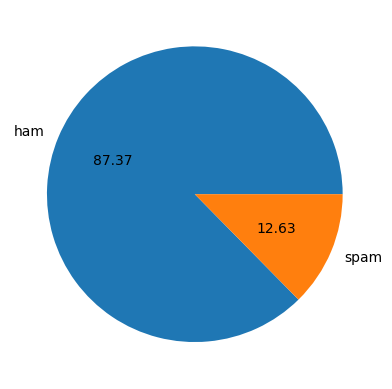

In [17]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct= "%0.2f")
plt.show()

In [18]:
nltk.download('punkt')
# nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\zoya1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
df['num_char'] = df['text'].apply(len)

In [20]:
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [21]:
df['text'].apply(lambda x:nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [22]:
df['num_words']= df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [23]:
df.head()

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [24]:
df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: text, Length: 5169, dtype: int64

In [25]:
df['num_sentence']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [26]:
df.head()

,target,text,num_char,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[['num_char','num_words','num_sentence']].describe()

,num_char,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
# ham message
df[df['target']==0 ] [['num_char', 'num_words', 'num_sentence']].describe()

,num_char,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# spam message
df[df['target']==1 ] [['num_char', 'num_words', 'num_sentence']].describe()

,num_char,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_words', ylabel='Count'>

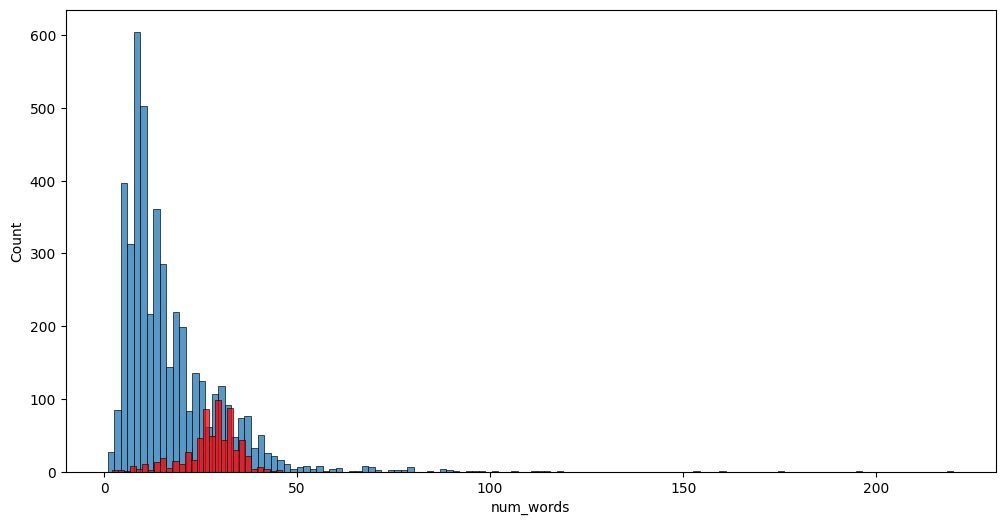

In [30]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'], color='red')

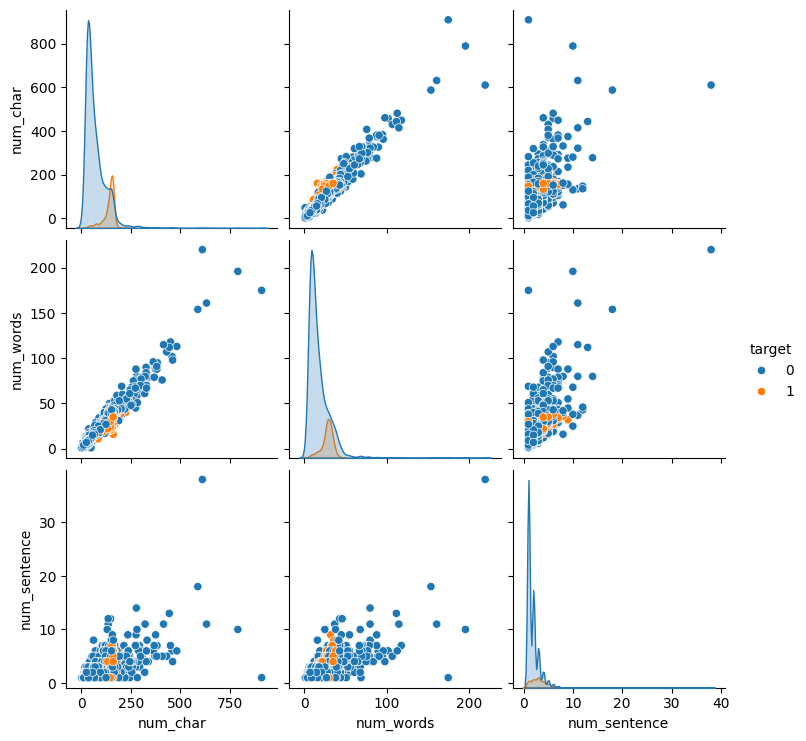

In [31]:
sns.pairplot(df,hue='target')

In [32]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[float, int])

# Calculate correlation matrix
numeric_df.corr()


,target,num_char,num_words,num_sentence
target,1.000000,0.384717,0.262912,0.263939
num_char,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentence,0.263939,0.624139,0.679971,1.000000


<Axes: >

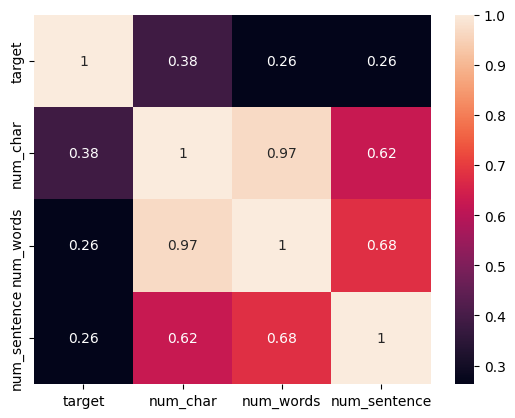

In [33]:
sns.heatmap(numeric_df.corr(),annot=True)

# 3. Data Processing
- lowercase
- tokenization
- removing special characters
- removing stop words and punctuations
- stemming

In [34]:
# def transform_text(text):
#     text=text.lower()
#     text = nltk.word_tokenize(text)

#     y= []
#     for i in text:
#             if i.isalnum():
#                     y.append(i)
#     text = y[:]
#     y.clear()
#     for i in text:
#         if i not in stopwords.words('english') and i not in string.punctuation:
#             y.append(i)       

#     for i in text:
#           y.append(ps.stem(i))     
#     return " ".join(y)



import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

# Downloads (Needed once per session)
nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()
STOPWORDS = set(stopwords.words('english'))

def transform_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Tokenization
    text = nltk.word_tokenize(text)
    
    # 3. Remove non-alphanumeric characters
    y = [i for i in text if i.isalnum()]
    
    # 4. Remove stopwords and punctuation
    # We filter 'y', then re-assign to 'y'
    y = [i for i in y if i not in STOPWORDS and i not in string.punctuation]
    
    # 5. Stemming
    y = [ps.stem(i) for i in y]
    
    return " ".join(y)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\zoya1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zoya1\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [35]:
# transform_text("How are You AMI")

In [36]:
# transform_text("Ami is 25 year old / this year")

In [37]:
# from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [38]:
# import string
# string.punctuation 
# from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
ps.stem('running')

'run'

In [39]:
df['text'].apply(transform_text)
# df['transformed_text'] = df['text'].fillna('').apply(transform_text)


0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                                b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: text, Length: 5169, dtype: object

In [40]:
df['transform_text'] = df['text'].apply(transform_text)

In [41]:
df.head(5)

,target,text,num_char,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [42]:
from wordcloud import WordCloud            # word cloud shows us the important words bigger
wc = WordCloud(width=500, height=500, min_font_size= 10, background_color='white')

In [43]:
spam_wc = wc.generate(df[df['target'] == 1]['transform_text'].str.cat(sep=" "))

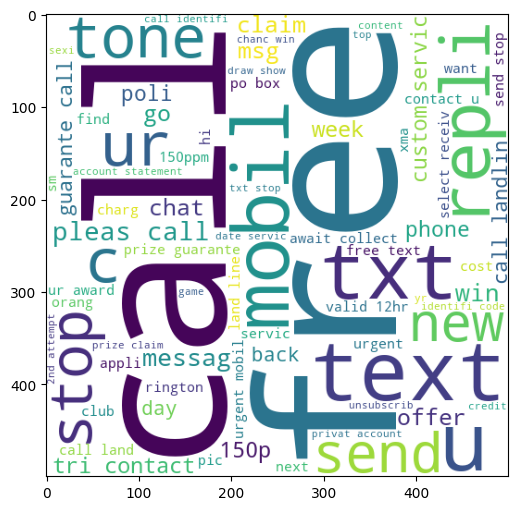

In [44]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [45]:
ham_wc = wc.generate(df[df['target'] == 0]['transform_text'].str.cat(sep=" "))


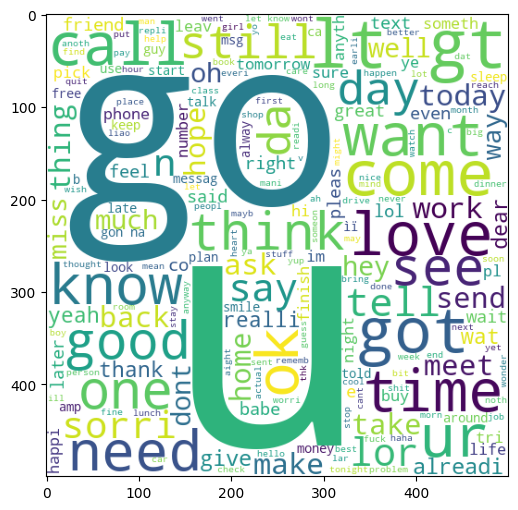

In [46]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)


In [47]:
spam_corpus = []
for msg in df[df['target'] ==1]['transform_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [48]:
len(spam_corpus)

9939

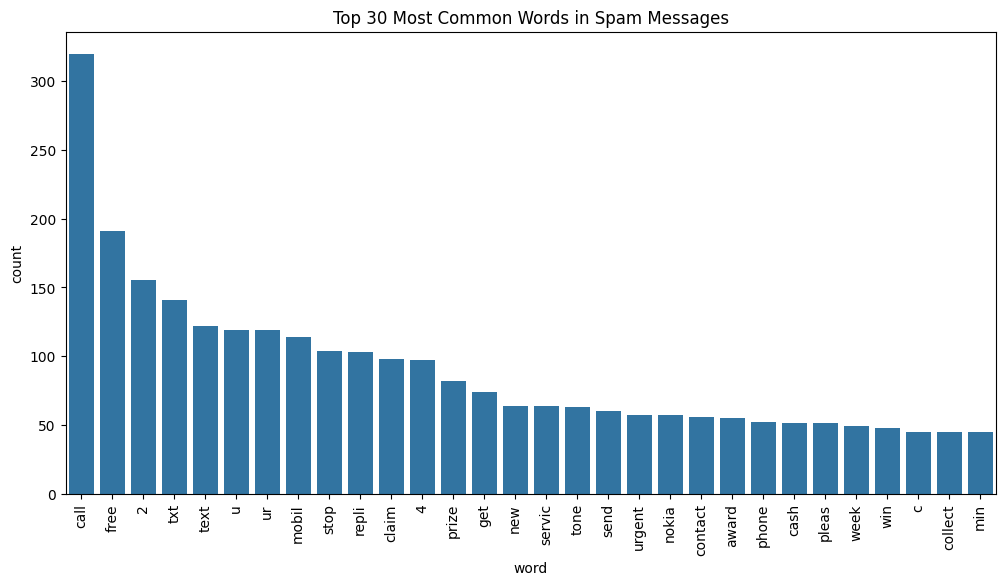

In [49]:

from collections import Counter
# Count word frequency
spam_freq = Counter(spam_corpus).most_common(30)

# Convert to DataFrame
df_spam_freq = pd.DataFrame(spam_freq, columns=['word', 'count'])

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='word', y='count', data=df_spam_freq)
plt.xticks(rotation=90)
plt.title("Top 30 Most Common Words in Spam Messages")
plt.show()

In [50]:
ham_corpus = []
for msg in df[df['target'] == 0]['transform_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)


In [51]:
len(ham_corpus)

35404

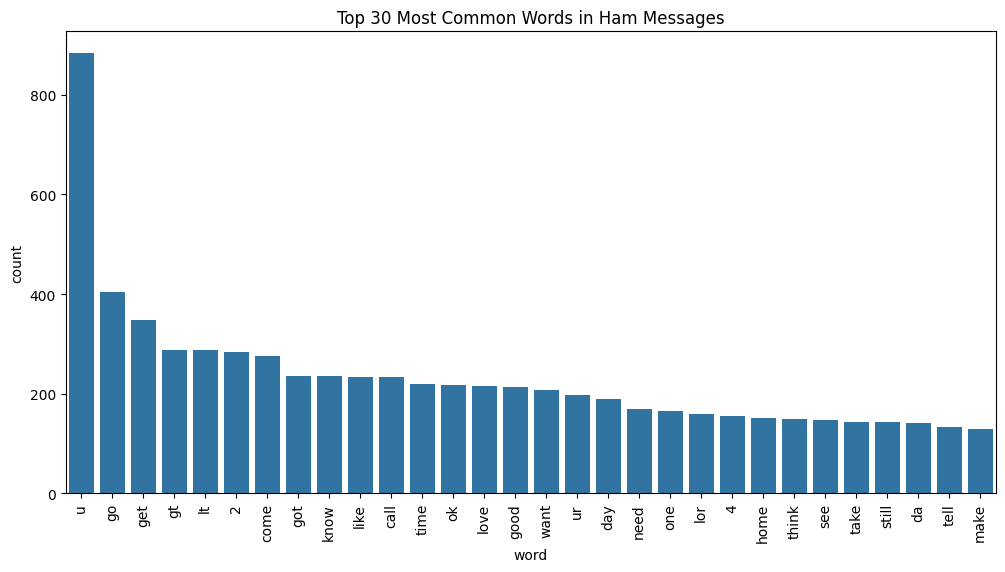

In [52]:

from collections import Counter
# Count word frequency
ham_freq = Counter(ham_corpus).most_common(30)

# Convert to DataFrame
df_ham_freq = pd.DataFrame(ham_freq, columns=['word', 'count'])

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='word', y='count', data=df_ham_freq)
plt.xticks(rotation=90)
plt.title("Top 30 Most Common Words in Ham Messages")
plt.show()

# Model Building

In [53]:
# from sklearn.feature_extraction.text import CountVectorizer

# cv = CountVectorizer()

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transform_text']).toarray()

y = df['target'].values

In [64]:
# X = cv.fit_transform(df['transform_text']).toarray()

In [65]:
X.shape

(5169, 3000)

In [66]:
y = df['target'].values

In [67]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [68]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [69]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [70]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))

Accuracy : 0.874274661508704
Confusion Matrix:
 [[790 106]
 [ 24 114]]
Precision: 0.5181818181818182


In [72]:
# mnb.fit(X_train, y_train)
# y_pred2 = mnb.predict(X_test)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
# Verify it works here first
# print(mnb.score(X_test, y_test))


# print("MultinomialNB Accuracy :", accuracy_score(y_test, y_pred2))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))
# print("Precision:", precision_score(y_test, y_pred2))


MultinomialNB()

In [73]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)

print("BernoulliNB Accuracy :", accuracy_score(y_test, y_pred3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))


BernoulliNB Accuracy : 0.9835589941972921
Confusion Matrix:
 [[895   1]
 [ 16 122]]
Precision: 0.991869918699187


In [74]:
# Import libraries
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Sample dataset
messages = [
    "Congratulations! You've won a $1000 gift card.",  # spam
    "Hey, are we still meeting for lunch today?",       # ham
    "URGENT! Your account has been compromised.",      # spam
    "Don't forget to bring the documents tomorrow.",  # ham
    "Win a free iPhone by clicking this link!",        # spam
    "Can you send me the notes from class?",           # ham
]

labels = [1, 0, 1, 0, 1, 0]  # 1 = spam, 0 = ham

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(messages, labels, test_size=0.33, random_state=42)

# Vectorize text data
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train the model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Test the model
y_pred = model.predict(X_test_vec)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Predict new messages
def predict_message(message):
    message_vec = vectorizer.transform([message])
    return "Spam" if model.predict(message_vec)[0] == 1 else "Ham"

# Test predictions
test_messages = [
    "You have won a lottery! Claim now.",
    "Win a free iPhone by clicking this link!",
    "Hey, let's watch a movie tonight.",
]

for msg in test_messages:
    print(f"Message: {msg}\nPrediction: {predict_message(msg)}\n")


Accuracy: 0.5
Confusion Matrix:
 [[1 0]
 [1 0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

Message: You have won a lottery! Claim now.
Prediction: Ham

Message: Win a free iPhone by clicking this link!
Prediction: Spam

Message: Hey, let's watch a movie tonight.
Prediction: Ham



C:\Users\zoya1\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zoya1\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\zoya1\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

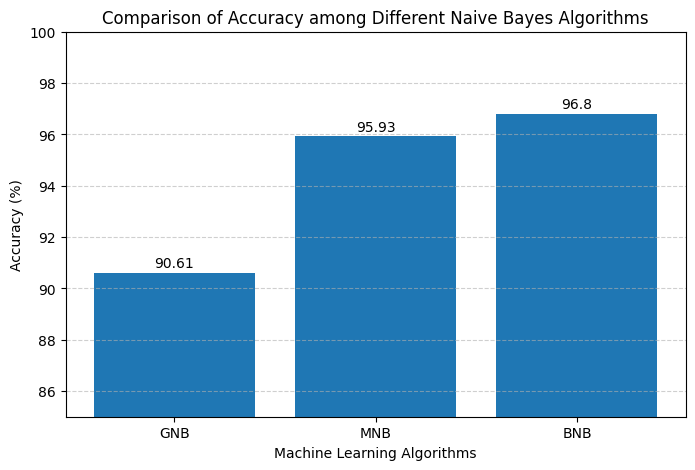

In [75]:
import matplotlib.pyplot as plt

# Algorithm names
algorithms = ['GNB', 'MNB', 'BNB']

# Accuracy values
accuracy = [90.61, 95.93, 96.80]

plt.figure(figsize=(8,5))
bars = plt.bar(algorithms, accuracy)

plt.xlabel("Machine Learning Algorithms")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Accuracy among Different Naive Bayes Algorithms")
plt.ylim(85, 100)

# value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, round(yval,2), ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

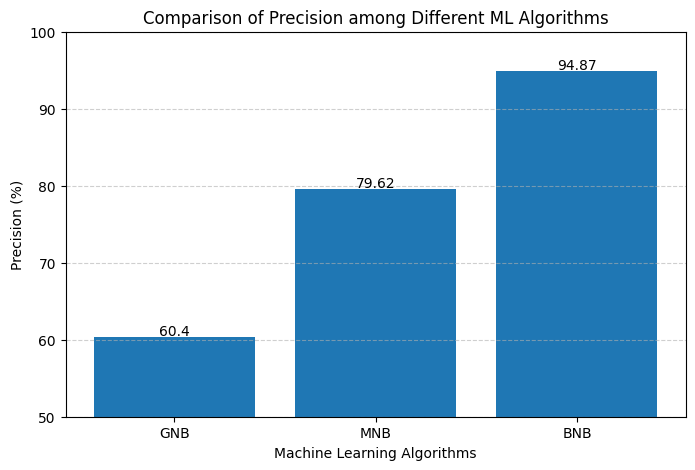

In [76]:
import matplotlib.pyplot as plt

algorithms = ['GNB', 'MNB', 'BNB']
precision = [60.40, 79.62, 94.87]

plt.figure(figsize=(8,5))
bars = plt.bar(algorithms, precision)

plt.xlabel("Machine Learning Algorithms")
plt.ylabel("Precision (%)")
plt.title("Comparison of Precision among Different ML Algorithms")
plt.ylim(50, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, round(yval,2), ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [78]:
import pickle
# Use 'wb' to overwrite the old, mismatched files
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))